<a href="https://colab.research.google.com/github/dhruvbit/Machine-project/blob/main/EMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms   # is torchvision is from cnn like image classification or it for regression
from torchvision import datasets
from torch.utils.data import DataLoader
from torch import optim
import torchvision.transforms.functional as F


In [24]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


In [25]:
data_path = './EMNIST_data'

#check if the data folder exist to avoid re downlaod
if os.path.exists(data_path) and os.path.isdir(data_path):
  download = False
  print("EMNIST Data folder found locally. Loading from local.\n")
else:
    download = True
    print("EMNIST Data folder not found locally. Downloading data.\n")

EMNIST Data folder found locally. Loading from local.



In [26]:
train_datasets = datasets.EMNIST(
    root = data_path,
    split='letters',
    train=True,
    download=download

)


test_datasets = datasets.EMNIST(
    root = data_path, #speicffy the root dir
    split = 'letters', #take out the subset of the datasets
    train = False,
    download = download
)

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score
from torchvision import datasets, transforms
from torchvision.transforms import functional as F


letter_ref = [
    "Dear Laurence",
    "Hope the PyTorch course is going well",
    "Do notforget to keep the labs interesting and engaging",
    "Maybe the students could decode my messy handwriting",
    "That might be a bit too challenging though",
    "I am impressed you are able to read this",
]


path_data = "./EMNIST_data"


def load_hidden_message_images(file_name="hidden_message_images.pkl"):
    """
    Loads hidden message images from a pickle file.

    Args:
        file_name (str): The name of the file to load the images from.

    Returns:
        message_imgs (list): A list containing the loaded message images.
    """
    # Open the specified file in read-binary mode
    with open(file_name, "rb") as f:
        # Import the pickle module
        import pickle

        # Load the data from the file
        message_imgs = pickle.load(f)

    # Return the loaded images
    return message_imgs


def decode_word_imgs(word_imgs, model, device):
    """
    Decodes a sequence of character images into a single word string using a
    provided classification model.

    Args:
        word_imgs (list): A collection of image tensors representing
            individual characters in a word.
        model (torch.nn.Module): The trained neural network model used to
            predict the character from the image.
        device (torch.device): The computation device to which the tensors
            should be moved before inference.

    Returns:
        decoded_word (str): The concatenated string of predicted characters
            forming the complete word.
    """
    # Set the model to evaluation mode
    model.eval()

    # Initialize an empty list to store the predicted characters
    decoded_chars = []

    # Disable gradient calculation for inference
    with torch.no_grad():
        # Iterate through each character image in the provided sequence
        for char_img in word_imgs:
            # Add a batch dimension to the tensor and move to target device
            char_img = char_img.unsqueeze(0).to(
                device
            )

            # Forward pass to predict the character probabilities
            output = model(char_img)

            # Extract the predicted class index with the highest probability
            _, predicted = output.max(1)

            # Retrieve the numerical value of the prediction
            predicted_label = predicted.item()

            # Convert the predicted label to corresponding lowercase letter
            lowercase_char = chr(ord("a") + predicted_label)

            # Append the predicted character to the list
            decoded_chars.append(f"{lowercase_char}")

    # Join the list of individual characters to form the final decoded word
    decoded_word = "".join(decoded_chars)

    # Return the final string
    return decoded_word


def visualize_image(img, label=None, ax=None):
    """
    Visualizes an EMNIST image with its label. If an axis is provided,
    plots on that axis; otherwise, creates a new figure.

    Args:
        img (np.ndarray): The image array to display.
        label (int): The numeric EMNIST label. If None, no title is shown.
        ax (matplotlib.axes.Axes): Axis to plot on. If None, creates a
            new figure.
    """
    # Check if the image is a PyTorch tensor and convert to numpy array
    if isinstance(img, torch.Tensor):
        # Squeeze the tensor to remove single-dimensional entries
        img = img.numpy().squeeze()
    # Check if the image is a numpy array
    elif isinstance(img, np.ndarray):
        # Check if the array has three dimensions
        if img.ndim == 3:
            # Extract the first channel of the image
            img = img[:, :, 0]

    # Check if a label is provided for the title
    if label is not None:
        # Convert the label to uppercase and lowercase characters
        uppercase_char, lowercase_char = convert_emnist_label_to_char(label)

        # Create a formatted title string
        title = f"EMNIST Letter: {uppercase_char}/{lowercase_char}"
    else:
        # Set the title to None if no label is provided
        title = None

    # Check if an axis is provided for plotting
    if ax is None:
        # Create a new figure and axis with specific dimensions
        fig, ax = plt.subplots(figsize=(5, 5))

        # Set a flag to display the colorbar
        show_colorbar = True
    else:
        # Disable the colorbar display
        show_colorbar = False

    # Display the image on the axis using a grayscale colormap
    im = ax.imshow(img, cmap="gray")

    # Set the x-axis tick marks
    ax.set_xticks(np.arange(0, 28, 1))

    # Set the y-axis tick marks
    ax.set_yticks(np.arange(0, 28, 1))

    # Set the size of the tick labels
    ax.tick_params(labelsize=6)

    # Enable the grid on the axis with specific color and transparency
    ax.grid(True, color="red", alpha=0.3)

    # Check if a title string was created
    if title:
        # Set the title of the axis
        ax.set_title(title)

    # Check if the colorbar flag is enabled
    if show_colorbar:
        # Add a colorbar to the plot
        plt.colorbar(im, ax=ax)

        # Display the plot
        plt.show()


def display_data_loader_contents(data_loader):
    """
    Displays the contents of the data loader including sizes and shapes.

    Args:
        data_loader (torch.utils.data.DataLoader): The data loader to
            display.
    """
    # Begin exception handling block
    try:
        # Print the total number of images in the dataset
        print("Total number of images in dataset:", len(data_loader.dataset))

        # Print the total number of batches in the data loader
        print("Total number of batches:", len(data_loader))

        # Iterate through the batches in the data loader
        for batch_idx, (data, labels) in enumerate(data_loader):
            # Print the current batch number
            print(f"--- Batch {batch_idx + 1} ---")

            # Print the shape of the data tensor
            print(f"Data shape: {data.shape}")

            # Print the shape of the labels tensor
            print(f"Labels shape: {labels.shape}")

            # Exit the loop after displaying the first batch
            break

    # Catch iteration exceptions if the data loader is empty
    except StopIteration:
        # Print a message indicating the data loader is empty
        print("data loader is empty.")

    # Catch any other general exceptions
    except Exception as e:
        # Print the specific error message
        print(f"An error occurred: {e}")


def evaluate_per_class(model, test_loader, device):
    """
    Evaluates the model's accuracy for each individual class.

    Args:
        model (torch.nn.Module): The trained PyTorch model.
        test_loader (torch.utils.data.DataLoader): DataLoader for the
            test dataset.
        device (torch.device): Device to run the model on.

    Returns:
        class_accuracies (dict): A dictionary containing accuracy for each
            class letter.
    """
    # Set the model to evaluation mode
    model.eval()

    # Initialize an empty list to store all target labels
    all_targets = []

    # Initialize an empty list to store all predicted labels
    all_predictions = []

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        # Iterate through inputs and targets in the test loader
        for inputs, targets in test_loader:
            # Move inputs and targets to the specified computation device
            inputs, targets = inputs.to(device), targets.to(device)

            # Shift target labels down by a single value
            targets = targets - 1

            # Generate model outputs from the inputs
            outputs = model(inputs)

            # Extract the highest probability predictions
            _, predicted = outputs.max(1)

            # Append the target labels to the storage list
            all_targets.extend(targets.cpu().numpy())

            # Append the predicted labels to the storage list
            all_predictions.extend(predicted.cpu().numpy())

    # Initialize an empty dictionary for class accuracies
    class_accuracies = {}

    # Iterate through the possible class indices
    for class_idx in range(26):
        # Extract targets matching the current class index
        class_targets = [
            t for t, p in zip(all_targets, all_predictions) if t == class_idx
        ]

        # Extract predictions matching the current class index
        class_predictions = [
            p for t, p in zip(all_targets, all_predictions) if t == class_idx
        ]

        # Check if there are any targets for the current class
        if len(class_targets) > 0:
            # Calculate and store the accuracy score for the class
            class_accuracies[chr(65 + class_idx)] = accuracy_score(
                class_targets, class_predictions
            )
        else:
            # Set a default accuracy of zero if the class is empty
            class_accuracies[chr(65 + class_idx)] = 0.0

    # Return the final dictionary of accuracies
    return class_accuracies


def save_student_model(model, filename="trained_student_model.pth"):
    """
    Saves the student's trained model and metadata to a file.

    Args:
        model (torch.nn.Module): The student's trained model.
        filename (str): The filename to save to.
    """
    # Create a dictionary containing the model state
    save_dict = {"model": model}

    # Save the dictionary to the specified file path
    torch.save(save_dict, filename)

    # Print a confirmation message indicating the save location
    print(f"Model saved to {filename}")


def convert_emnist_label_to_char(label):
    """
    Converts an EMNIST label to corresponding uppercase and lowercase letters.

    Args:
        label (int): The numeric EMNIST label.

    Returns:
        char_tuple (tuple): A tuple containing the uppercase and lowercase
            characters.
    """
    # Check if the label is within the valid range
    if not (1 <= label <= 26):
        # Raise an error if the label is invalid
        raise ValueError("Label must be between 1 and 26 inclusive.")

    # Calculate the uppercase character based on the label
    uppercase_char = chr(64 + label)

    # Calculate the lowercase character based on the label
    lowercase_char = chr(96 + label)

    # Group characters into a tuple variable
    char_tuple = (uppercase_char, lowercase_char)

    # Return the character tuple
    return char_tuple

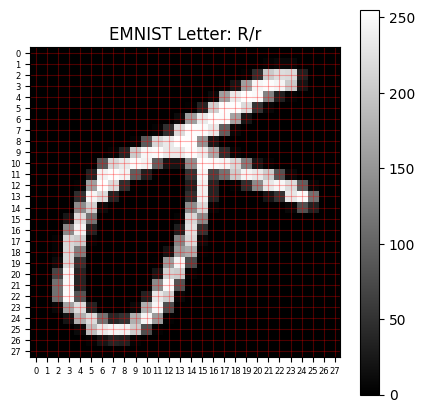

image type <class 'PIL.Image.Image'>


In [28]:
index=90000 #pick an index from the training set
img,label = train_datasets[index]
visualize_image(img,label)
print(f"image type {type(img)}")


# the img is flip and rotate also

In [29]:
### preprocessing img ####

In [30]:
mean = (0.1736,)
std = (0.3317,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std)
])


#assign the transform to both the training and test
train_datasets.transform = transform
test_datasets.transform  =transform

In [31]:
index = 90000
img_tensor,label = train_datasets[index]
print(img_tensor)

tensor([[[-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.4761, -0.4288, -0.4288, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.4879,  0.0323,
           1.8648,  2.0894,  2.0421, -0.1450, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0

In [32]:
#Keep in mind that this step is only for visualization.
#It helps you interpret the images more easily. The dataset itself remains unchanged,
#and the model will still train on the original, uncorrected data.

In [33]:
def correct_image_orientation(image):
  rotated = F.rotate(image,90)
  flipped = F.vflip(rotated)

  img_transform = correct_image_orientation(img_tensor)
  visualize_image(img_transform, label)

In [34]:
def create_emnist_dataloader(train_datasets,test_datasets , batch_size=64):
  train_dataloader = torch.utils.data.DataLoader(
      dataset=train_datasets,
      batch_size=batch_size,
      shuffle=True

  )

  test_dataloader = torch.utils.data.DataLoader(
      dataset=test_datasets,
      batch_size=batch_size,
      shuffle=False
  )

  return train_dataloader, test_dataloader

In [35]:
train_loader, test_loader = create_emnist_dataloader(train_datasets, test_datasets, batch_size=64)

print("--- Train Loader --- \n")
display_data_loader_contents(train_loader)
print("\n--- Test Loader --- \n")
display_data_loader_contents(test_loader)

--- Train Loader --- 

Total number of images in dataset: 124800
Total number of batches: 1950
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])

--- Test Loader --- 

Total number of images in dataset: 20800
Total number of batches: 325
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [40]:
def initialize_emnist_model(num_classes=26):
    """
    Initializes a sequential neural network model for EMNIST classification.

    Initializes a sequential neural network model for EMNIST classification.

    Args:
        num_classes (int): The number of output classes. Defaults to 26.

    Returns:
        tuple: A tuple containing the model, loss function, and optimizer.
               (model, loss_function, optimizer)
    """


    torch.manual_seed(42)  # Set seed for reproducibility

    ### START CODE HERE ###

    # Define the neural network model using nn.Sequential
    model =nn.Sequential(
        # Flatten the input images
        nn.Flatten(),
        # Middle part should not have more than 5 layers. Only Linear and ReLU layers.
        # Note: Hidden layer units should not exceed 256
        nn.Linear(28*28,128),
        nn.ReLU(),
        nn.Linear(128,64),
        # Final Layer: SHOULD be Linear Layer
        # Output layer with shape nn.Linear(valid inputs to the layer, num_classes outputs)
        nn.ReLU(),
        nn.Linear(64,num_classes)
    )


    # Define the loss function (Cross-Entropy Loss for multi-class classification)
    loss_function = nn.CrossEntropyLoss()

    # Define the optimizer (Adaptive Moment Estimation)
    optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

    ### END CODE HERE ###

    return model, loss_function, optimizer

In [41]:
your_model, loss_func, optimizer = initialize_emnist_model(num_classes=26)

print(f"Your model's architecture:\n\n{your_model}\n")
print(f"Your model's loss function: {loss_func}\n")
print(f"Your model's optimizer:\n\n{optimizer}\n")

Your model's architecture:

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=26, bias=True)
)

Your model's loss function: CrossEntropyLoss()

Your model's optimizer:

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

